<a href="https://colab.research.google.com/github/GR8KALI12/Kalidasan_Github_Portfolio/blob/main/Final_Assignment_Part_1_Create_Visualizations_using_Matplotlib%2C_Seaborn_%26_Folium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [ ]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [ ]:
df.columns
#df.dtypes

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [ ]:
df_new = df[['Consumer_Confidence','Seasonality_Weight','Advertising_Expenditure','Competition','GDP','Growth_Rate','unemployment_rate']]

In [ ]:
df_new.describe()

,Consumer_Confidence,Seasonality_Weight,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,101.210890,0.737756,2879.743655,6.118845,40.205748,-0.237074,2.441525
std,10.634092,0.286092,1175.338324,1.964292,16.291271,0.859691,1.108472
min,73.900000,0.250000,494.200000,3.000000,12.510000,-4.230000,1.000000
25%,94.060000,0.500000,1872.000000,4.000000,27.210000,-0.570000,1.600000
50%,100.800000,0.810000,2883.500000,6.000000,39.420000,-0.005000,2.300000
75%,108.320000,0.940000,3902.425000,8.000000,53.862500,0.392500,2.900000
max,131.670000,1.500000,4983.000000,9.000000,70.370000,0.820000,6.000000


## TASK 1.1: Develop a Line chart using the functionality of pandas to show how Average automobile sales fluctuate from year to year

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [ ]:
#df.reset_index(inplace=True)
df['Year'].unique()

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

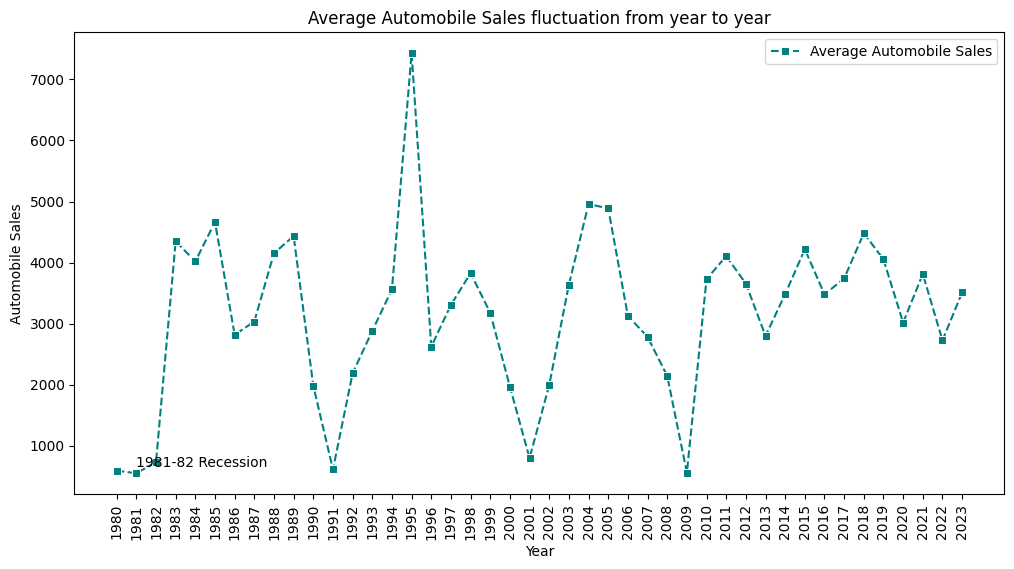

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reset the index to ensure 'Year' is a column for grouping and plotting.
# This handles cases where 'Year' might have been set as index in previous runs.
# We create a temporary DataFrame `df_plot` to perform these operations.
df_plot = df.reset_index()

# Calculate the average automobile sales for each year
df_avg_sales = df_plot.groupby('Year')['Automobile_Sales'].mean().reset_index()

#Defining the size of the figure -
plt.figure(figsize=(12, 6))

# Create the line plot
sns.lineplot(x='Year', y='Automobile_Sales', data=df_avg_sales, marker='s', color='teal',linestyle='--',label='Average Automobile Sales')

plt.xlabel('Year')
plt.xticks(list(range(1980,2024)),rotation=90)
plt.text(x=1981,y=650,s='1981-82 Recession')
plt.ylabel('Automobile Sales')
plt.title('Average Automobile Sales fluctuation from year to year')
plt.legend()
plt.show()

TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship

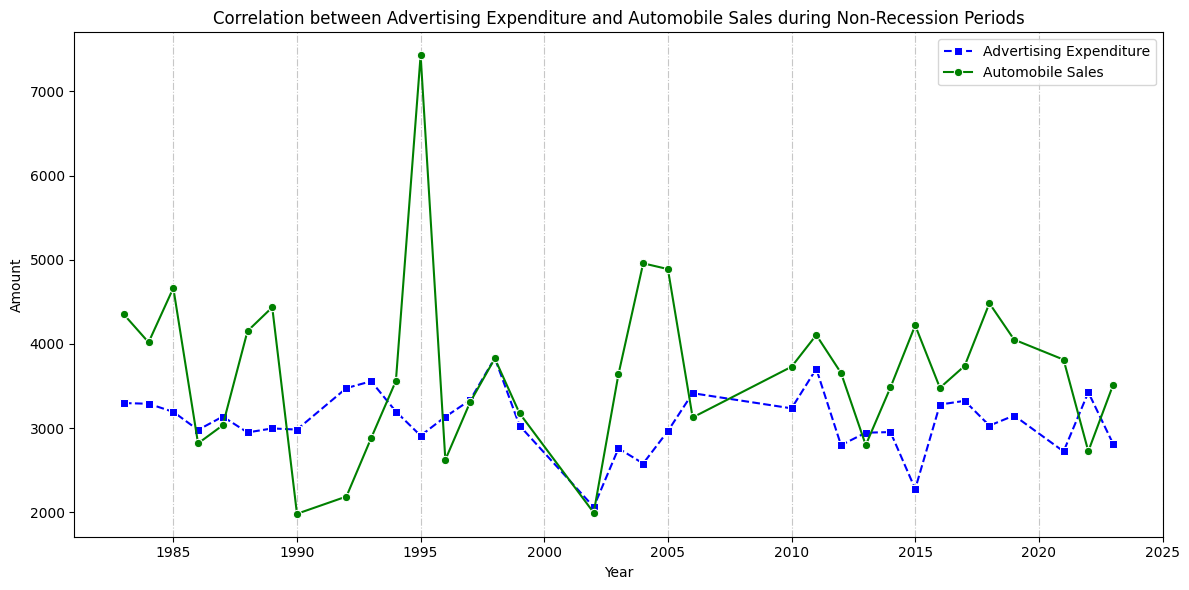

In [ ]:
from matplotlib.typing import LineStyleType
#Start by filtering the dataset to include only non-recession periods where the "Recession" column has a value of 0.
df_nonrec = df[df['Recession'] == 0]

#Group data
df_trends = df_nonrec.groupby(df_nonrec['Year'])[['Advertising_Expenditure','Automobile_Sales']].mean()

df_nonrec.reset_index(inplace=True)

plt.figure(figsize=(12,6))
sns.lineplot(x='Year',y='Advertising_Expenditure',data=df_trends,marker='s',color='blue',linestyle='--',label='Advertising Expenditure')
sns.lineplot(x='Year',y='Automobile_Sales',data=df_trends,marker='o',color='green',linestyle='-',label='Automobile Sales')

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Amount')
plt.title('Correlation between Advertising Expenditure and Automobile Sales during Non-Recession Periods')
plt.legend()
plt.grid(axis='x', linestyle='-.', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
df_nonrec[['Advertising_Expenditure','Automobile_Sales']].corr()

,Advertising_Expenditure,Automobile_Sales
Advertising_Expenditure,1.000000,-0.011717
Automobile_Sales,-0.011717,1.000000


### TASK 1.3: Use the functionality of **Seaborn Library** to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.


In [ ]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

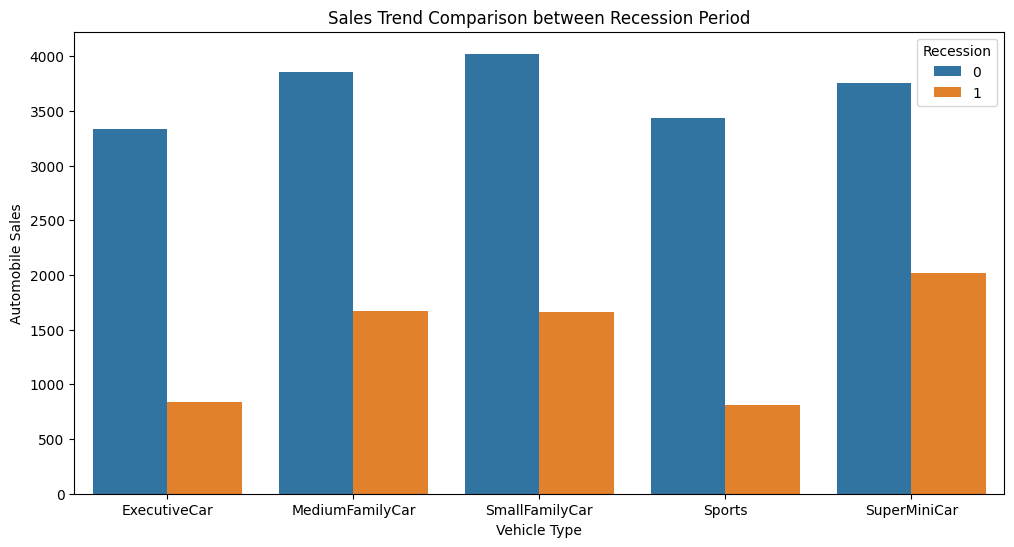

In [ ]:
dfrectrends = df[['Recession','Vehicle_Type','Automobile_Sales']]


#grouping the data by vehicle type and taking the sales trend
dfrectrends = dfrectrends.groupby(['Vehicle_Type','Recession'])['Automobile_Sales'].mean()

#reset the index
dfrectrends = dfrectrends.reset_index()

#plot the bar graph
plt.figure(figsize=(12,6))
sns.barplot(x='Vehicle_Type',y='Automobile_Sales',hue='Recession',data=dfrectrends)
plt.xlabel('Vehicle Type')
plt.ylabel('Automobile Sales')
#plt.text(axis = 0, rotation=90)
plt.title('Sales Trend Comparison between Recession Period')
plt.show()

In [ ]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


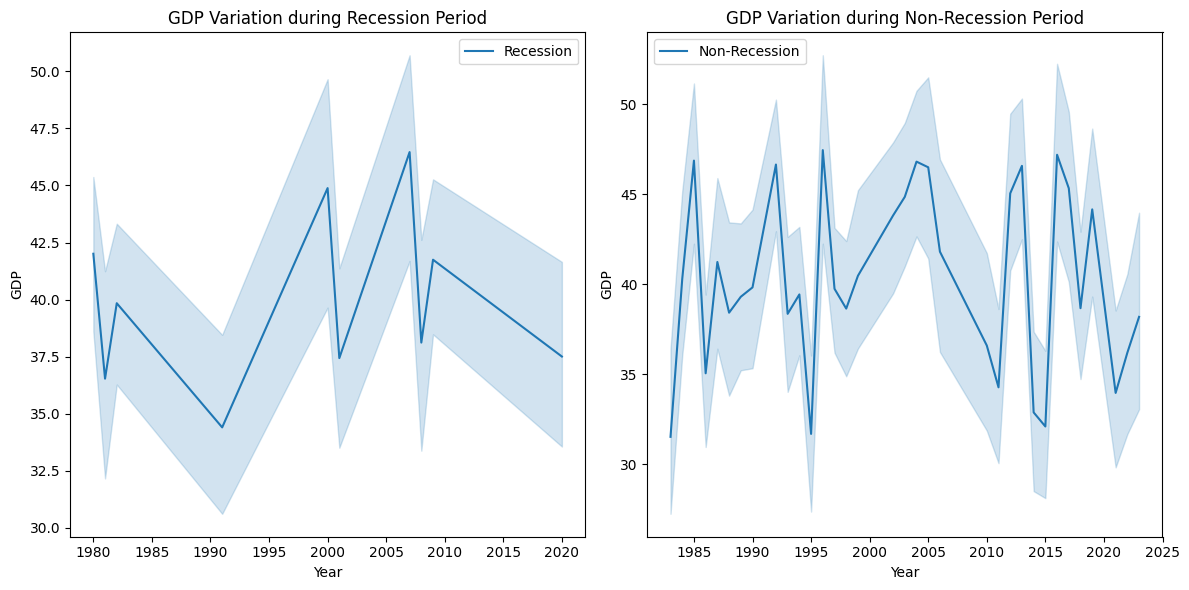

In [ ]:
#Create the table segregrated based on Recession state
df_rec =df[df['Recession'] == 1]
df_nonrec = df[df['Recession'] == 0]

fig = plt.figure(figsize=(12,6))

#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1,2,2) # add subplot 2 (1 row, 2 columns, second plot).

#plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=df_rec, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

#plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=df_nonrec, label='Non-Recession',ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()


## TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales

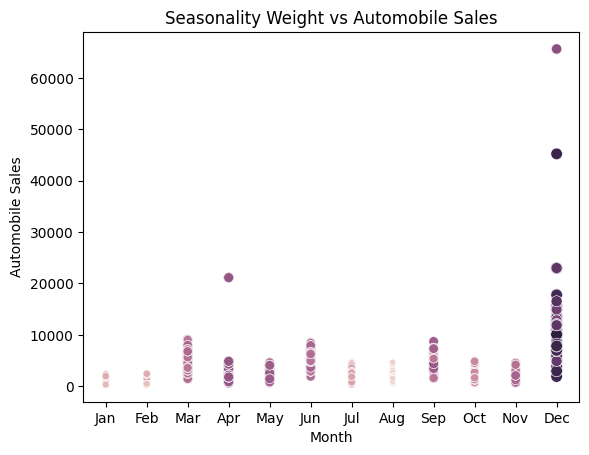

In [ ]:
sns.scatterplot(x=df_nonrec['Month'],y=df_nonrec['Automobile_Sales'],data=df_nonrec,size=df_nonrec['Seasonality_Weight'],legend=False
                ,hue=df_nonrec['Seasonality_Weight'])
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Weight vs Automobile Sales')
plt.show()

TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.

In [ ]:
df_rec.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


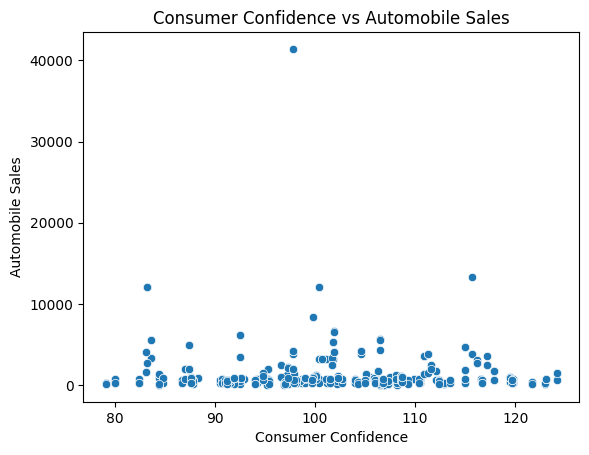

In [ ]:
sns.scatterplot(x=df_rec['Consumer_Confidence'],y=df_rec['Automobile_Sales'],data=df_rec,#(size=df_nonrec['Seasonality_Weight'],
                )
                #hue=df_nonrec['Seasonality_Weight'])
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence vs Automobile Sales')
plt.show()

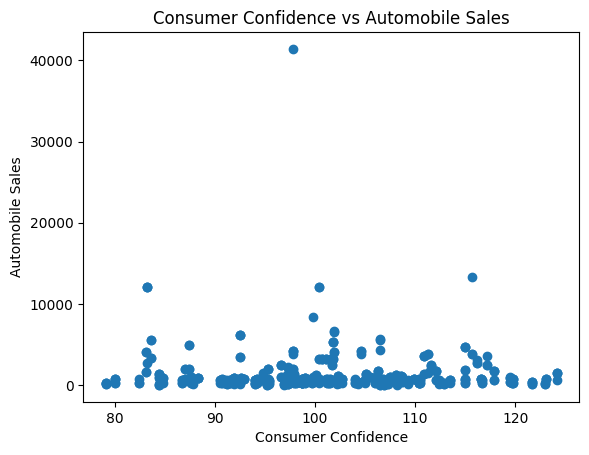

In [ ]:
plt.scatter(df_rec['Consumer_Confidence'],df_rec['Automobile_Sales'])
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence vs Automobile Sales')
plt.show()

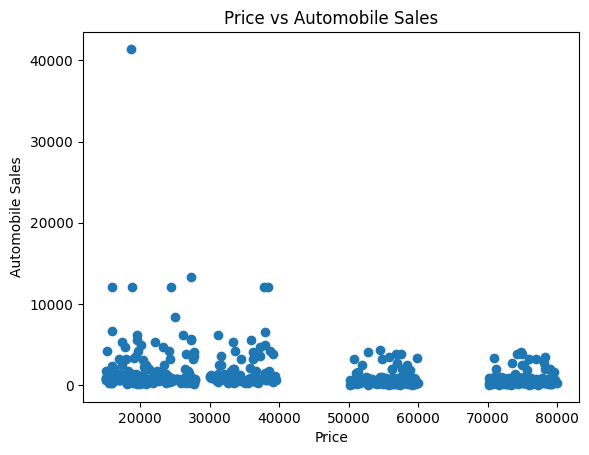

In [ ]:
plt.scatter(df_rec['Price'],df_rec['Automobile_Sales'])
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Price vs Automobile Sales')
plt.show()

In [ ]:
dfadsum = dfexp / dfexp.sum() * 100
dfadsum

,Advertising_Expenditure
Recession,
0,82.720941
1,17.279059


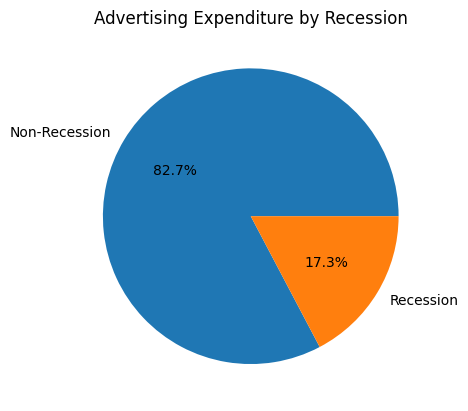

In [ ]:
dfexp=df.groupby('Recession')['Advertising_Expenditure'].sum()
dfexp

plt.pie(x=dfexp,labels=['Non-Recession','Recession'],data=dfexp,autopct='%1.1f%%')
plt.title('Advertising Expenditure by Recession')
plt.show()

# TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

In [ ]:
df_rec1 = df_rec1/df_rec1.sum()*100
df_rec1.sort_values(ascending=False)

In [ ]:
df_rec1 = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.pie(df_rec1,labels=df_rec1.index,autopct='%1.1f%%')
plt.title('Advertising Expenditure by Vehicle Type')
plt.show()

# TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period

In [ ]:
df_rec.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [ ]:
rec_data.dtypes

,0
Vehicle_Type,object
Automobile_Sales,float64
unemployment_rate,float64


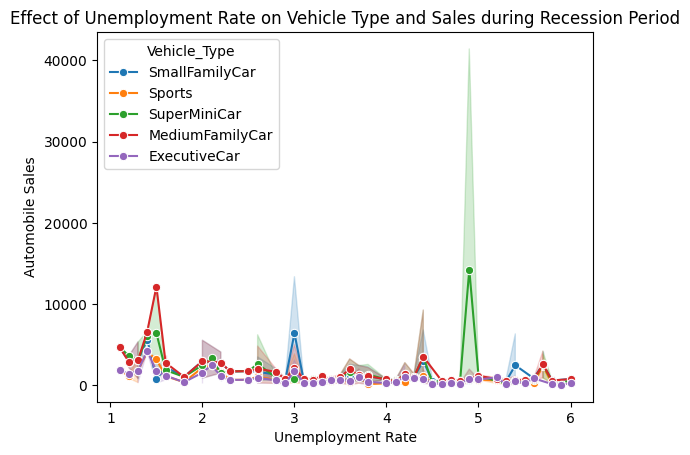

In [ ]:
rec_data = df_rec[['Vehicle_Type','Automobile_Sales','unemployment_rate']]
sns.lineplot(x=rec_data['unemployment_rate'],y=rec_data['Automobile_Sales'],hue=rec_data['Vehicle_Type'],marker='o')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales during Recession Period')
plt.show()

### OPTIONAL : TASK 1.10 Create a map on the hightest sales region/offices of the company during recession period


In [ ]:
import requests

def download_file_requests(url, filename):
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes
    with open(filename, "wb") as f:
        f.write(response.content)

path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'
download_file_requests(path, "us-states.json")

filename = "us-states.json"

In [ ]:
import json
import pandas as pd

# Load the JSON file into a Python dictionary
with open('us-states.json', 'r') as f:
    states_json_data = json.load(f)

# Convert the 'features' part of the JSON data into a pandas DataFrame
# This assumes the 'features' key contains a list of dictionaries, which is common in GeoJSON
# The actual structure might require further normalization if deeply nested.
df_states = pd.DataFrame(states_json_data['features'])

print("DataFrame created from us-states.json:")
display(df_states.head())

DataFrame created from us-states.json:


,type,id,properties,geometry
0,Feature,AL,{'name': 'Alabama'},"{'type': 'Polygon', 'coordinates': [[[-87.3592..."
1,Feature,AK,{'name': 'Alaska'},"{'type': 'MultiPolygon', 'coordinates': [[[[-1..."
2,Feature,AZ,{'name': 'Arizona'},"{'type': 'Polygon', 'coordinates': [[[-109.042..."
3,Feature,AR,{'name': 'Arkansas'},"{'type': 'Polygon', 'coordinates': [[[-94.4738..."
4,Feature,CA,{'name': 'California'},"{'type': 'Polygon', 'coordinates': [[[-123.233..."


In [ ]:
import folium

# State name to abbreviation mapping
state_names_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Apply the mapping to create a 'State_Abbr' column in the recession data
df_rec = df[df['Recession'] == 1].copy()
df_rec['State_Abbr'] = df_rec['City'].map(state_names_to_abbr)

# Drop rows where State_Abbr is NaN (cities not mapped to known states for a state-level choropleth)
df_rec_mapped = df_rec.dropna(subset=['State_Abbr'])

# Group by 'State_Abbr' and sum 'Automobile_Sales'
sales_by_state = df_rec_mapped.groupby('State_Abbr')['Automobile_Sales'].sum().reset_index()

# Initialize a base Folium Map (e.g., centered on the US) to which the choropleth will be added
us_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)


/tmp/ipykernel_2463/500494116.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rec['State_Abbr'] = df_rec['City'].map(state_names_to_abbr)


In [ ]:
# Define the folium Choropleth layer
folium.Choropleth(
    geo_data=states_json_data, # Use the loaded GeoJSON data
    data=sales_by_state, # Use the aggregated sales data
    columns=['State_Abbr', 'Automobile_Sales'], # Specify the columns for mapping
    key_on='feature.id', # Matches 'State_Abbr' with 'id' in geo_data
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Automobile Sales During Recession'
).add_to(us_map)

# Display the map. In Colab/Jupyter, the last expression in a cell is displayed.
us_map